In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("gym_members_exercise_tracking.csv")

In [2]:
# Dataframe loading has been moved to the first cell for better initialization.

In [3]:
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

In [5]:
df.shape

(973, 15)

In [6]:
df.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


In [7]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [8]:
df['Workout_Type'].unique()

array(['Yoga', 'HIIT', 'Cardio', 'Strength'], dtype=object)

In [9]:
df.isnull().sum()

,0
Age,0
Gender,0
Weight (kg),0
Height (m),0
Max_BPM,0
Avg_BPM,0
Resting_BPM,0
Session_Duration (hours),0
Calories_Burned,0
Workout_Type,0


<Axes: xlabel='Calories_Burned', ylabel='Count'>

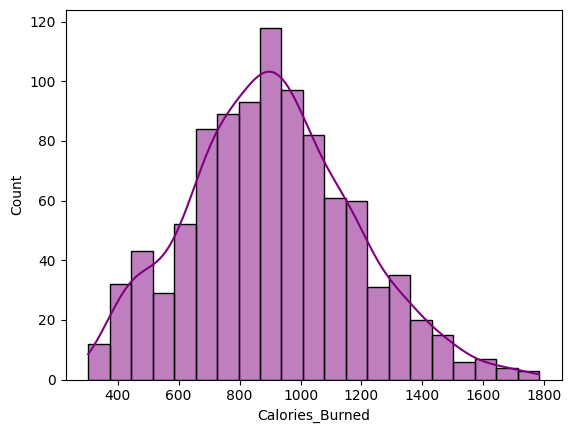

In [10]:
sns.histplot(df['Calories_Burned'],kde=True,color='purple')

In [11]:
df['Calories_Burned'].skew()

np.float64(0.2783210950013363)

<Axes: >

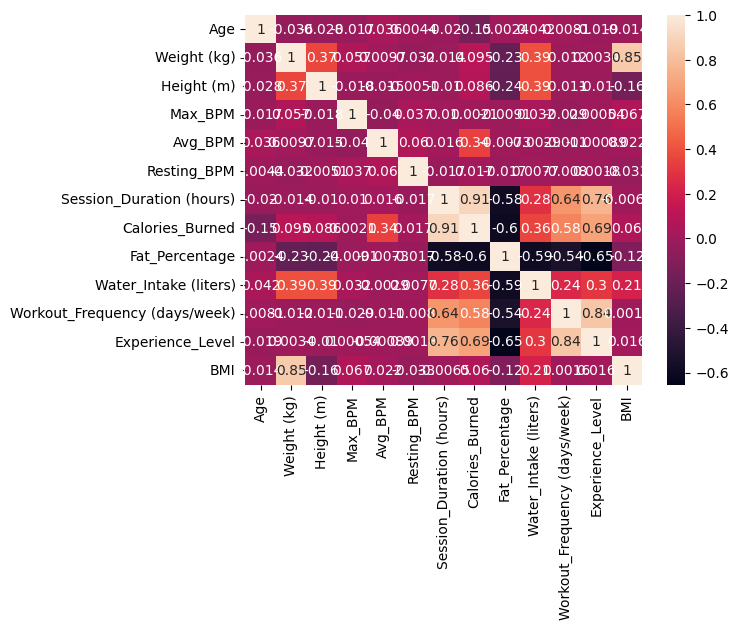

In [12]:
# coorelation between heatmap and numerical features
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)

ENCODED

In [13]:
df['Gender'] = df['Gender'].map({'Male':0,'Female':1})


  ONE HOT ENCODED

In [14]:
df = pd.get_dummies(df,columns=['Workout_Type'])

In [15]:
X = df.drop('Calories_Burned',axis=1)
y = df['Calories_Burned']

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
#


In [18]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)


LinearRegression()

In [19]:
y_pred = model.predict(X_test)
y_pred

array([ 913.29290198, 1416.98008645,  956.02333033, 1109.33442077,
       1504.42816055, 1303.88950325,  961.04415039,  938.7838832 ,
       1039.39092111, 1195.97433571, 1313.60332721,  628.21742592,
        851.22564408,  760.88413274,  785.42457018,  673.70973106,
        931.62792235, 1115.27174795,  932.53126309,  436.55189907,
        908.48197172,  799.50513059,  820.08140965,  884.04762723,
        477.61068726,  726.8086326 ,  927.00489337,  398.58952919,
        957.76069577, 1134.6890281 ,  781.51011599,  932.62099835,
        602.34355059, 1156.21698813, 1251.58612052, 1469.08204256,
        638.67578741,  982.26963969,  661.45198494,  452.14711356,
        328.74710898,  699.12442629,  317.2023949 ,  656.25528849,
        912.61401325,  955.0163229 ,  755.19423795,  882.68330685,
        771.38281251,  929.96570099, 1007.00100178, 1149.67051442,
       1081.61697331, 1258.89212039,  780.29887002, 1358.92692527,
        704.20441226,  448.97607408,  427.72917595,  713.65541

In [20]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

r2_score(y_test,y_pred)

0.9802675995368527

In [21]:
r2_score(y_train,model.predict(X_train))

0.9789133535430258

In [22]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
print(f"MAE: {mae}")
print(f"MSE: {mse}")

MAE: 30.270139845320685
MSE: 1646.1760145970452


In [23]:
import joblib
joblib.dump(model,'model.pkl')

['model.pkl']

## Data Visualization

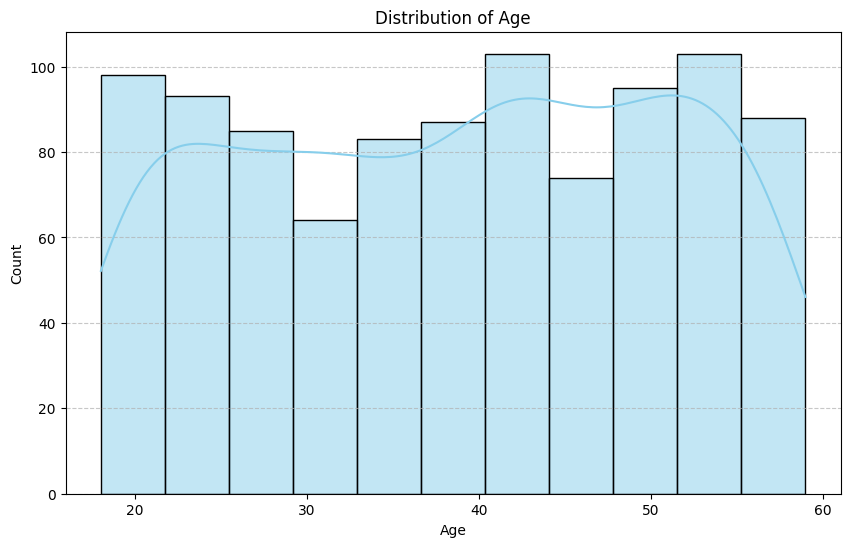

In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

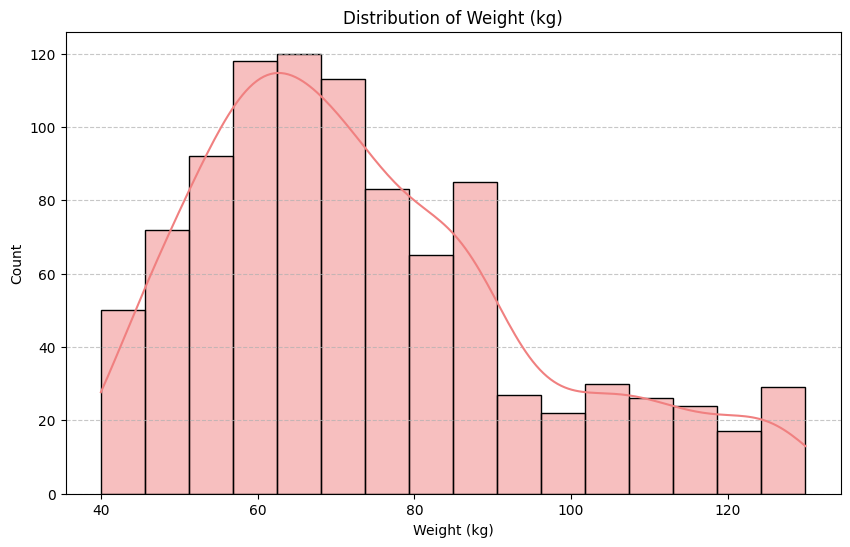

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Weight (kg)'], kde=True, color='lightcoral')
plt.title('Distribution of Weight (kg)')
plt.xlabel('Weight (kg)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

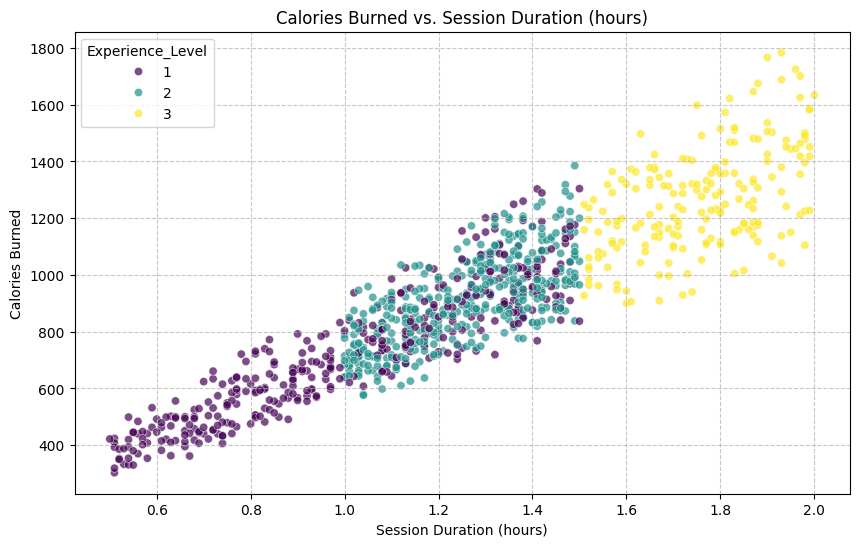

In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Session_Duration (hours)', y='Calories_Burned', data=df, hue='Experience_Level', palette='viridis', alpha=0.7)
plt.title('Calories Burned vs. Session Duration (hours)')
plt.xlabel('Session Duration (hours)')
plt.ylabel('Calories Burned')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_5919/1802574050.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Original_Workout_Type', y='Calories_Burned', data=df, palette='plasma')


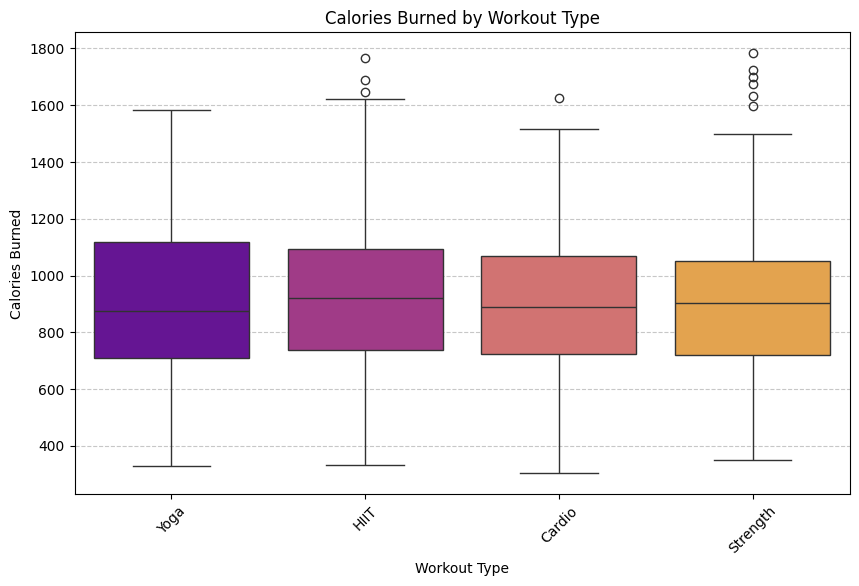

In [27]:
# To plot 'Workout_Type', we need to reverse the one-hot encoding for visualization purposes, or plot from original df if available.
# Assuming we want to visualize the impact of original Workout_Type before one-hot encoding for the model.
# If not, we would need to sum calories for each workout type column for visualization.
# Let's use the original 'Workout_Type' column if available or recreate it for plotting.

# For plotting purposes, let's look at the original Workout_Type column from before one-hot encoding.
# If you've already dropped the original 'Workout_Type' column, you might need to reload the data or create a temporary column.
# Assuming df_original was the dataframe before one-hot encoding or that Workout_Type columns are still usable.

# If df is already one-hot encoded, we can plot using a temporary series:
workout_types = [col for col in df.columns if col.startswith('Workout_Type_')]
# Create a Series that maps back to the original workout type for plotting
def get_original_workout_type(row):
    for wt in workout_types:
        if row[wt] == 1:
            return wt.replace('Workout_Type_', '')
    return 'Unknown'

df['Original_Workout_Type'] = df.apply(get_original_workout_type, axis=1)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Original_Workout_Type', y='Calories_Burned', data=df, palette='plasma')
plt.title('Calories Burned by Workout Type')
plt.xlabel('Workout Type')
plt.ylabel('Calories Burned')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.show()

# Drop the temporary column
df = df.drop(columns=['Original_Workout_Type'])

/tmp/ipykernel_5919/1442438328.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender_Label', y='Calories_Burned', data=df_plot, palette='coolwarm')


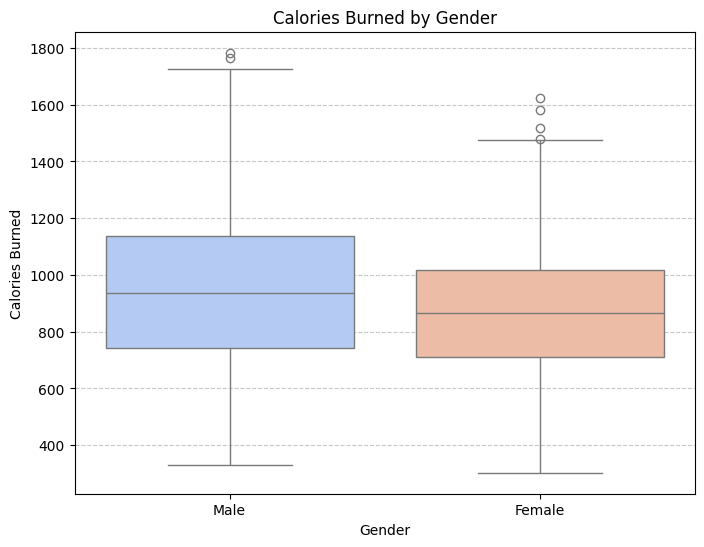

In [28]:
# For gender, we need to map back 0 and 1 to Male and Female for better visualization
df_plot = df.copy()
df_plot['Gender_Label'] = df_plot['Gender'].map({0: 'Male', 1: 'Female'})

plt.figure(figsize=(8, 6))
sns.boxplot(x='Gender_Label', y='Calories_Burned', data=df_plot, palette='coolwarm')
plt.title('Calories Burned by Gender')
plt.xlabel('Gender')
plt.ylabel('Calories Burned')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()